# Libraries for EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I. Read files and store the data

In [2]:
df = pd.read_csv("ObesityDataset.csv")

## Get all the numerical and categorical columns

In [3]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# II. Annalyze the numerical columns

* See what columns in the dataset is numerical

In [4]:
numerical_cols

['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

In [5]:
df_numerical = df[numerical_cols]
df_numerical.describe()

,Age,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000


## Handling the outliers

In [6]:
def count_outliers_iqr(df, columns):
    outlier_counts = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outlier_counts[col] = outliers
    
    # Create result DataFrame
    result = pd.DataFrame(list(outlier_counts.items()), 
                         columns=['Column', 'Outlier_Count'])
    result['Percentage'] = (result['Outlier_Count'] / len(df) * 100).round(2)
    
    return result


def fix_outliers_iqr(df, columns):
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)
        
    return df_clean

def plot_outlier_comparison(df_before, df_after, columns):
    sns.set_style("whitegrid")

    n_cols = len(columns)
    
    fig, axes = plt.subplots(n_cols, 2, figsize=(14, 5 * n_cols))
    
    if n_cols == 1:
        axes = [axes]

    for i, col in enumerate(columns):
        # Plot Before
        sns.boxplot(data=df_before, x=col, ax=axes[i][0], color='salmon')
        axes[i][0].set_title(f'Original Distribution: {col}', fontsize=12, fontweight='bold')
        axes[i][0].set_xlabel('')
        
        # Plot After
        sns.boxplot(data=df_after, x=col, ax=axes[i][1], color='lightgreen')
        axes[i][1].set_title(f'After Capping: {col}', fontsize=12, fontweight='bold')
        axes[i][1].set_xlabel('')

    plt.tight_layout()
    plt.show()

## Before handling outliers

In [7]:
result = count_outliers_iqr(df_numerical, numerical_cols)
result

,Column,Outlier_Count,Percentage
0,Age,168,7.96
1,FCVC,0,0.00
2,NCP,579,27.43
3,CH2O,0,0.00
4,FAF,0,0.00
5,TUE,0,0.00


## After handling outliers

In [8]:
fix_cols = ['Age', 'NCP']
new_numerical = fix_outliers_iqr(df_numerical, fix_cols)
new_result = count_outliers_iqr(new_numerical, numerical_cols)
new_result

,Column,Outlier_Count,Percentage
0,Age,0,0.0
1,FCVC,0,0.0
2,NCP,0,0.0
3,CH2O,0,0.0
4,FAF,0,0.0
5,TUE,0,0.0


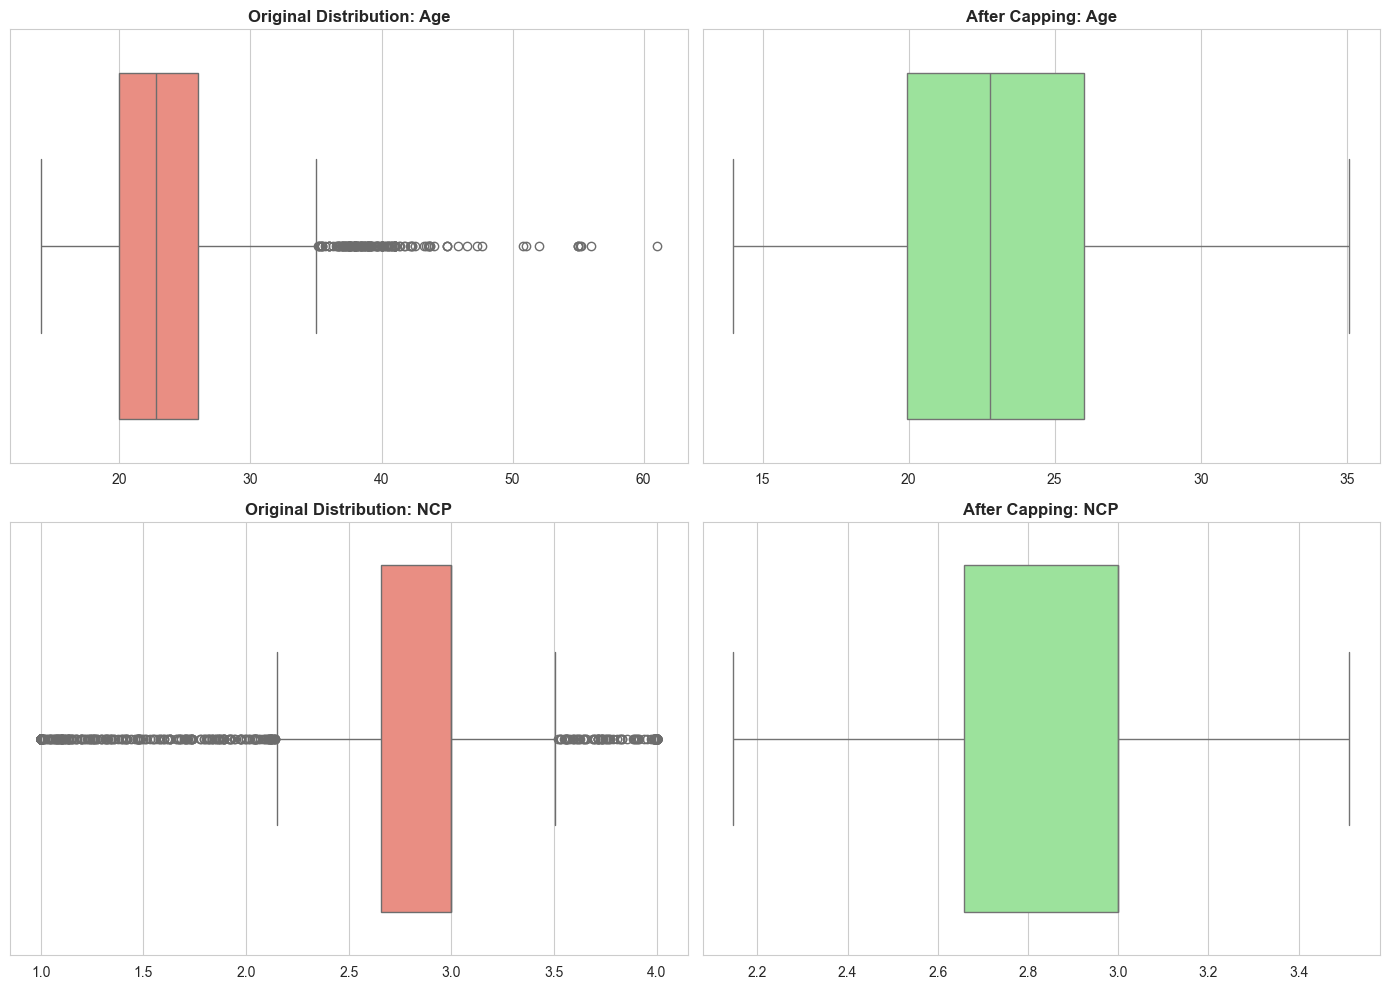

In [9]:
plot_outlier_comparison(df_numerical, new_numerical, fix_cols)

* Storing the new data

In [10]:
new_numerical.describe()

,Age,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,23.910277,2.419043,2.835525,2.008011,1.010298,0.657866
std,5.277434,0.533927,0.400898,0.612953,0.850592,0.608927
min,14.000000,1.000000,2.146845,1.000000,0.000000,0.000000
25%,19.947192,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,3.000000,3.000000,2.477420,1.666678,1.000000
max,35.079212,3.000000,3.511893,3.000000,3.000000,2.000000


# III. Analyzing the categorical columns

In [11]:
df_categorical = df[categorical_cols]
for col in categorical_cols:
    unique_list = df_categorical[col].unique()
    print(f"Col {col} have {len(unique_list)} : {unique_list} ")

Col Gender have 2 : ['Female' 'Male'] 
Col family_history_with_overweight have 2 : ['yes' 'no'] 
Col FAVC have 2 : ['no' 'yes'] 
Col CAEC have 4 : ['Sometimes' 'Frequently' 'Always' 'no'] 
Col SMOKE have 2 : ['no' 'yes'] 
Col SCC have 2 : ['no' 'yes'] 
Col CALC have 4 : ['no' 'Sometimes' 'Frequently' 'Always'] 
Col MTRANS have 5 : ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike'] 
Col NObeyesdad have 7 : ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III'] 


# IV. Storing into new file with no outliers

In [12]:
df_preprocessed = pd.concat([new_numerical, df_categorical], axis=1)

In [13]:
cols = df_preprocessed.columns
cols

Index(['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Gender',
       'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [14]:
df_preprocessed.to_csv("ObesityDataset_no_outlier.csv")